# Whistleblower's Dilemma — Analysis

This notebook reproduces the main analyses and figures of the paper.
It loads the per-(model, perspective, run) inference CSVs from `results/`,
scores the free-text reasoning with the eMFD dictionary, and produces:

1. Overall yes-ratio (report-rate) by perspective
2. Report-ratio heatmaps over (closeness × severity)
3. KDE of report-ratio distributions across models
4. Radar plots of moral-foundation profiles
5. Per-foundation OLS slopes vs. closeness/severity
6. Yes-vs-No moral-ratio comparison (bar plot)


In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import statsmodels.api as sm
from matplotlib.colors import TwoSlopeNorm
from matplotlib.lines import Line2D

from src.scoring.mfd2_processing_utils import (
    get_model_result_df_dict,
    compute_report_ratio,
)


## 1. Load + score all model outputs

We score 6 models across 3 perspectives × 3 runs each. Setting
`combine_runs=True` aggregates `{prescriptive,descriptive,action}_{1,2,3}`
under a single `perspective` column with values `prescriptive`/`descriptive`/`action`.

In [ ]:
MODEL_NAMES = [
    'claude-3.5-haiku',
    'gemini-2.5-pro',
    'gpt-5-mini-2025-08-07',
    'o3-mini-2025-01-31',
    'deepseek-chat-v3.1',
    'qwen3-30b-a3b-thinking-2507',
]

PERSPECTIVE_RUNS = [
    'prescriptive_1', 'prescriptive_2', 'prescriptive_3',
    'descriptive_1', 'descriptive_2', 'descriptive_3',
    'action_1', 'action_2', 'action_3',
]

MODEL_NAME_MAP = {
    'claude-3.5-haiku': 'Claude 3.5 Haiku',
    'gemini-2.5-pro': 'Gemini 2.5 Pro',
    'gpt-5-mini-2025-08-07': 'GPT-5 mini',
    'o3-mini-2025-01-31': 'o3-mini',
    'qwen3-30b-a3b-thinking-2507': 'Qwen3 30B A3B Thinking',
    'deepseek-chat-v3.1': 'DeepSeek-V3.1',
}

PERSPECTIVE_TITLE_MAP = {
    'prescriptive': 'Moral Rightness',
    'descriptive': 'Predicted Human Behavior',
    'action': "LLM's Decision",
}

PERSPECTIVE_COLORS = {
    'prescriptive': '#ff7f0e',
    'descriptive': '#2ca02c',
    'action': '#9467bd',
}

all_dilemma_score_df, all_dilemma_stat_df = get_model_result_df_dict(
    MODEL_NAMES, PERSPECTIVE_RUNS, moral_measurement='mfd', combine_runs=True,
)
all_dilemma_score_df.shape, all_dilemma_stat_df.shape

In [3]:
all_dilemma_stat_df


,model,perspective,response_rate,overall_yes_ratio,closeness1_severity4_yes_ratio,closeness4_severity1_yes_ratio
0,claude-3.5-haiku,action,2.982,0.789,1.000,0.414
1,claude-3.5-haiku,descriptive,2.987,0.279,0.701,0.037
2,claude-3.5-haiku,prescriptive,2.988,0.879,1.000,0.632
3,gemini-2.5-pro,action,2.998,0.872,1.000,0.455
4,gemini-2.5-pro,descriptive,2.998,0.352,0.975,0.017
5,gemini-2.5-pro,prescriptive,2.998,0.873,1.000,0.420
6,gpt-5-mini-2025-08-07,action,2.998,0.976,0.992,0.790
7,gpt-5-mini-2025-08-07,descriptive,2.999,0.368,0.749,0.128
8,gpt-5-mini-2025-08-07,prescriptive,2.999,0.972,1.000,0.761
9,o3-mini-2025-01-31,action,3.000,0.961,1.000,0.794


## 2. Overall yes-ratio by perspective


/tmp/ipykernel_3781799/2720310698.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(perspective_labels)


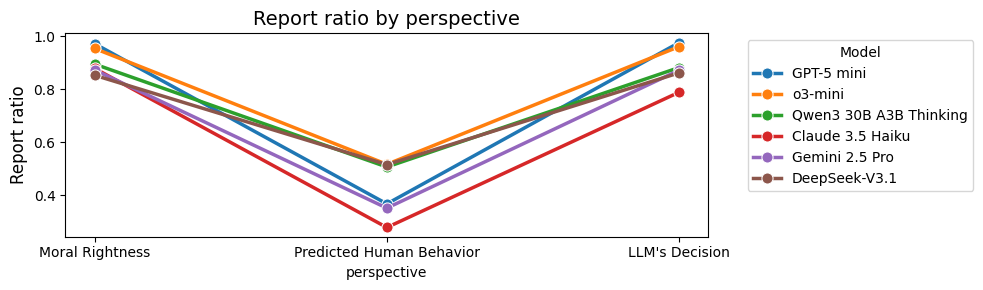

In [4]:
def plot_overall_yes_ratio_line(stat_df, perspective_order=None,
                                 model_name_map=None, perspective_labels=None):
    df = stat_df.copy()
    if perspective_order is not None:
        df['perspective'] = pd.Categorical(
            df['perspective'], categories=perspective_order, ordered=True,
        )
        first_df = df[df['perspective'] == perspective_order[0]]
    else:
        first_df = df.groupby('model').mean(numeric_only=True).reset_index()

    model_order = first_df.sort_values('overall_yes_ratio', ascending=False)['model'].tolist()
    df['model'] = pd.Categorical(df['model'], categories=model_order, ordered=True)

    plt.figure(figsize=(10, 3))
    ax = sns.lineplot(
        data=df, x='perspective', y='overall_yes_ratio',
        hue='model', hue_order=model_order,
        marker='o', markersize=8, linewidth=2.5, palette='tab10',
    )
    plt.title('Report ratio by perspective', fontsize=14)
    plt.ylabel('Report ratio', fontsize=12)
    if perspective_labels is not None:
        ax.set_xticklabels(perspective_labels)

    handles, labels = ax.get_legend_handles_labels()
    if model_name_map is not None:
        labels = [model_name_map.get(l, l) for l in labels]
    ax.legend(handles, labels, title='Model',
              bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    ax.grid(False)
    plt.show()


plot_overall_yes_ratio_line(
    all_dilemma_stat_df,
    perspective_order=['prescriptive', 'descriptive', 'action'],
    model_name_map=MODEL_NAME_MAP,
    perspective_labels=['Moral Rightness', 'Predicted Human Behavior', "LLM's Decision"],
)


## 3. Report-ratio heatmaps over (closeness × severity)


In [5]:
report_ratio_score_df = compute_report_ratio(all_dilemma_score_df)
report_ratio_score_df.head()


,closeness_level,closeness_level_name,severity_level,model,perspective,report_ratio,care_ratio,fairness_ratio,loyalty_ratio,authority_ratio
0,1,stranger,1,claude-3.5-haiku,action,0.599174,0.320641,0.323741,0.128955,0.208068
1,1,stranger,1,claude-3.5-haiku,descriptive,0.111111,0.363964,0.259542,0.090679,0.164416
2,1,stranger,1,claude-3.5-haiku,prescriptive,0.699588,0.372822,0.277192,0.089673,0.226706
3,1,stranger,1,deepseek-chat-v3.1,action,0.831776,0.309345,0.240392,0.137743,0.295732
4,1,stranger,1,deepseek-chat-v3.1,descriptive,0.497942,0.277371,0.288058,0.132741,0.248332


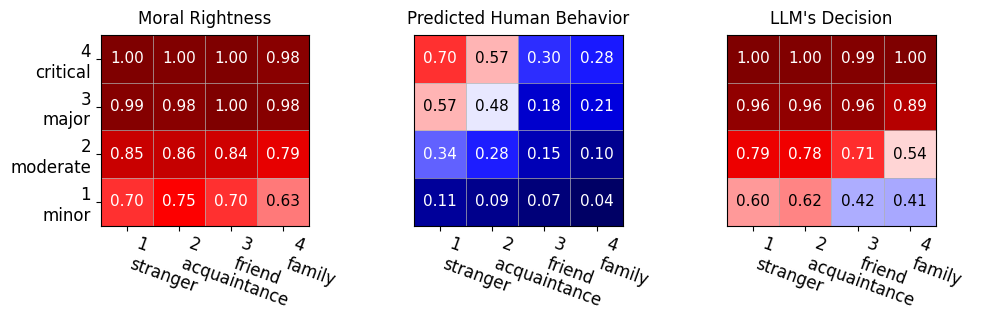

In [6]:
def _auto_text_color(rgba, threshold=0.52):
    r, g, b = rgba[:3]
    luminance = 0.2126 * r + 0.7152 * g + 0.0722 * b
    return 'white' if luminance < threshold else 'black'


def plot_report_ratio_heatmaps(
    report_ratio_df,
    perspective_order=('prescriptive', 'descriptive', 'action'),
    closeness_order=(1, 2, 3, 4),
    cmap='seismic',
    vmin=0.0, vmax=1.0, vcenter=0.5,
    figsize_per_cell=(3.2, 3),
    annotate=True,
    round_digits=2,
    annot_fontsize=11,
    perspective_title_map=None,
    add_colorbar=False,
    cbar_width=0.018,
    cbar_pad=0.02,
):
    df = report_ratio_df.copy()
    if perspective_title_map is None:
        perspective_title_map = PERSPECTIVE_TITLE_MAP

    df['severity_level'] = pd.to_numeric(df['severity_level'], errors='coerce')
    df['closeness_level'] = pd.to_numeric(df['closeness_level'], errors='coerce')
    df['report_ratio'] = pd.to_numeric(df['report_ratio'], errors='coerce')

    models = sorted(df['model'].dropna().unique().tolist())
    perspectives = [p for p in perspective_order if p in set(df['perspective'].dropna().unique())]
    severity_levels = sorted(df['severity_level'].dropna().unique().tolist())
    closeness_order = list(closeness_order)

    name_map = (
        df.dropna(subset=['closeness_level', 'closeness_level_name'])
          .drop_duplicates(subset=['closeness_level'])
          .set_index('closeness_level')['closeness_level_name']
          .to_dict()
    )
    x_ticklabels = [f"{lvl}\n{name_map.get(lvl, '')}".rstrip() for lvl in closeness_order]

    severity_name_map = {1: 'minor', 2: 'moderate', 3: 'major', 4: 'critical'}

    n_rows, n_cols = len(models), len(perspectives)
    figsize = (figsize_per_cell[0] * n_cols, figsize_per_cell[1] * n_rows)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, squeeze=False)
    norm = TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
    last_im = None

    for r, model in enumerate(models):
        for c, perspective in enumerate(perspectives):
            ax = axes[r, c]
            sub = df[(df['model'] == model) & (df['perspective'] == perspective)]
            mat = (
                sub.pivot_table(
                    index='severity_level', columns='closeness_level',
                    values='report_ratio', aggfunc='mean',
                ).reindex(index=severity_levels, columns=closeness_order)
            )
            data = mat.to_numpy(dtype=float)
            masked = np.ma.masked_invalid(data)

            im = ax.imshow(masked, aspect='auto', cmap=cmap, norm=norm, origin='lower')
            last_im = im

            if annotate:
                for i in range(masked.shape[0]):
                    for j in range(masked.shape[1]):
                        val = masked[i, j]
                        if np.ma.is_masked(val) or np.isnan(val):
                            continue
                        rgba = im.cmap(im.norm(float(val)))
                        ax.text(j, i, f'{float(val):.{round_digits}f}',
                                ha='center', va='center',
                                fontsize=annot_fontsize,
                                color=_auto_text_color(rgba))

            if r == 0:
                ax.set_title(perspective_title_map.get(perspective, perspective),
                             fontsize=12, pad=8)
            if c == 0:
                ax.set_yticks(np.arange(len(severity_levels)))
                ax.set_yticklabels(
                    [f"{int(s)}\n{severity_name_map.get(int(s), '')}"
                     if float(s).is_integer() else str(s)
                     for s in severity_levels],
                    fontsize=12,
                )
            else:
                ax.set_yticks([])
                ax.set_ylabel('')

            if r == n_rows - 1:
                ax.set_xticks(np.arange(len(closeness_order)))
                ax.set_xticklabels(x_ticklabels, rotation=340, ha='left', fontsize=12)
            else:
                ax.set_xticks([])
                ax.set_xlabel('')

            ax.set_xticks(np.arange(-0.5, len(closeness_order), 1), minor=True)
            ax.set_yticks(np.arange(-0.5, len(severity_levels), 1), minor=True)
            ax.grid(which='minor', linestyle='-', linewidth=0.5)
            ax.tick_params(which='minor', bottom=False, left=False)

    if add_colorbar and last_im is not None:
        right_margin = 1.0 - (cbar_width + cbar_pad + 0.02)
        fig.tight_layout(rect=[0, 0, right_margin, 1], pad=0.0, w_pad=0.05, h_pad=0.05)
        x0 = right_margin + cbar_pad - 0.05
        height = 0.4
        y0 = (1.0 - height) / 2.0 + 0.13
        cax = fig.add_axes([x0, y0, cbar_width, height])
        fig.colorbar(last_im, cax=cax)
    else:
        fig.tight_layout(pad=0.0)
        fig.subplots_adjust(wspace=0.5, hspace=0.4)
    return fig, axes


fig, _ = plot_report_ratio_heatmaps(
    report_ratio_score_df[report_ratio_score_df['model'] == 'claude-3.5-haiku'],
)
plt.show()


## 4. KDE distribution of report-ratio per perspective × model


In [ ]:
def plot_model_perspective_distribution(
    df,
    model_name_map=None,
    perspective_name_map=None,
    perspective_colors=None,
    model_order=None,
    ncols=3,
    xlim=(0, 1),
    xtick_step=0.2,
    show_xlabels_on_bottom_only=True,
    show_model_name=True,
    y_expand=1.35,
    save_path=None,
):
    if model_order is not None:
        models = [m for m in model_order if m in df['model'].unique()]
    elif model_name_map:
        models = [m for m in model_name_map.keys() if m in df['model'].unique()]
    else:
        models = list(df['model'].unique())

    if perspective_name_map:
        perspectives = [p for p in perspective_name_map.keys() if p in df['perspective'].unique()]
    else:
        perspectives = list(df['perspective'].unique())

    if perspective_colors:
        palette = {p: perspective_colors.get(p) for p in perspectives}
        missing = [p for p in perspectives if palette[p] is None]
        if missing:
            extra = dict(zip(missing, sns.color_palette('Set1', len(missing))))
            for p in missing:
                palette[p] = extra[p]
    else:
        palette = dict(zip(perspectives, sns.color_palette('Set1', len(perspectives))))

    n_models = len(models)
    nrows = math.ceil(n_models / ncols)
    fig, axes = plt.subplots(nrows, ncols,
                              figsize=(5.2 * ncols, 2.8 * nrows),
                              sharex=True, sharey=False)
    axes = np.array(axes).reshape(-1)
    xticks = np.arange(xlim[0], xlim[1] + 1e-9, xtick_step)

    legend_handles = [
        mpatches.Patch(color=palette[p],
                       label=perspective_name_map.get(p, p) if perspective_name_map else p)
        for p in perspectives
    ]
    legend_labels = [
        perspective_name_map.get(p, p) if perspective_name_map else p
        for p in perspectives
    ]

    for i, (ax, model) in enumerate(zip(axes, models)):
        subset = df[df['model'] == model]
        sns.kdeplot(
            data=subset, x='report_ratio', hue='perspective',
            hue_order=perspectives, common_norm=False, palette=palette,
            ax=ax, linewidth=2, fill=True, alpha=0.45, cut=2, legend=False,
        )

        y_top = ax.get_ylim()[1] * y_expand
        ax.set_ylim(0, y_top)
        base_y = y_top * 0.70

        # Median lines + numeric labels with offset to avoid overlap.
        cluster_tol = 0.035
        step_pts = 38
        margin_data = 0.015

        def _dx_data_per_pt(x_ref):
            x0_disp, y0_disp = ax.transData.transform((x_ref, base_y))
            x1_disp, y1_disp = (x0_disp + (fig.dpi / 72.0), y0_disp)
            x1_data, _ = ax.transData.inverted().transform((x1_disp, y1_disp))
            return x1_data - x_ref

        medians = []
        for p in perspectives:
            vals = subset[subset['perspective'] == p]['report_ratio']
            if len(vals) == 0:
                continue
            mval = float(vals.median())
            medians.append((p, mval))
            ax.axvline(mval, color=palette[p], linestyle='--', alpha=0.85, linewidth=1.0)

        if medians:
            medians_sorted = sorted(medians, key=lambda x: x[1])
            clusters, cur = [], [medians_sorted[0]]
            for item in medians_sorted[1:]:
                if abs(item[1] - cur[-1][1]) <= cluster_tol:
                    cur.append(item)
                else:
                    clusters.append(cur); cur = [item]
            clusters.append(cur)

            priority = {'prescriptive': 0, 'descriptive': 1, 'action': 2}
            for cluster in clusters:
                cluster_sorted = sorted(cluster, key=lambda x: priority.get(x[0], 999))
                k = len(cluster_sorted)
                offsets = np.arange(k) * step_pts - ((k - 1) / 2.0) * step_pts
                x_ref = float(np.mean([m for _, m in cluster_sorted]))
                dx_per_pt = _dx_data_per_pt(x_ref) or 1e-6

                anchors = [m + off * dx_per_pt for off, (_, m) in zip(offsets, cluster_sorted)]
                xmin, xmax = xlim
                over = max(anchors) - (xmax - margin_data)
                if over > 0:
                    offsets = offsets - over / dx_per_pt
                anchors = [m + off * dx_per_pt for off, (_, m) in zip(offsets, cluster_sorted)]
                under = (xmin + margin_data) - min(anchors)
                if under > 0:
                    offsets = offsets + under / dx_per_pt

                for off, (p, mval) in zip(offsets, cluster_sorted):
                    ax.annotate(
                        f'{mval:.2f}', xy=(mval, base_y),
                        xytext=(off, 0), textcoords='offset points',
                        color=palette[p], va='bottom', ha='right',
                        fontsize=11, fontweight='bold',
                    )

        ax.set_xlim(*xlim)
        ax.set_xticks(xticks)
        ax.tick_params(axis='x', labelsize=12, length=4, width=1)

        if show_xlabels_on_bottom_only:
            row_idx = i // ncols
            if row_idx == nrows - 1:
                ax.set_xlabel('Report ratio', fontsize=14, labelpad=8)
            else:
                ax.set_xlabel('')
                ax.tick_params(axis='x', labelbottom=False)
        else:
            ax.set_xlabel('Report ratio', fontsize=14, labelpad=8)

        ax.set_ylabel('')
        ax.set_yticks([])
        ax.grid(False)
        for spine in ['top', 'right', 'left', 'bottom']:
            ax.spines[spine].set_visible(True)
            ax.spines[spine].set_linewidth(1.2)

        if show_model_name:
            display_name = model_name_map.get(model, model) if model_name_map else model
            ax.set_title(display_name, fontsize=16, pad=5)

    for j in range(len(models), len(axes)):
        fig.delaxes(axes[j])

    fig.legend(
        legend_handles, legend_labels,
        loc='lower center', bbox_to_anchor=(0.5, 0.0),
        ncol=len(perspectives), frameon=False,
        fontsize=15, handlelength=1.6, columnspacing=1.6,
    )
    plt.tight_layout(rect=[0.02, 0.10, 0.98, 0.98])
    if save_path:
        fig.savefig(save_path, bbox_inches='tight')
    plt.show()


model_order = [
    'gemini-2.5-pro', 'qwen3-30b-a3b-thinking-2507', 'deepseek-chat-v3.1',
    'gpt-5-mini-2025-08-07', 'o3-mini-2025-01-31', 'claude-3.5-haiku',
]

plot_model_perspective_distribution(
    report_ratio_score_df,
    model_name_map=MODEL_NAME_MAP,
    perspective_name_map=PERSPECTIVE_TITLE_MAP,
    perspective_colors=PERSPECTIVE_COLORS,
    model_order=model_order,
)

## 5. Radar plots: moral-foundation profile per (model, perspective)


In [ ]:
def plot_moral_radar(
    df, models, perspectives=('prescriptive', 'descriptive', 'action'),
    moral_cols=('fairness_ratio', 'loyalty_ratio', 'authority_ratio', 'care_ratio'),
    r_range=(0, 0.45),
    fill_alpha=0.1,
    model_name_map=None,
    save_path=None,
):
    moral_cols = list(moral_cols)
    labels = [c.replace('_ratio', '').capitalize() for c in moral_cols]
    perspectives = list(perspectives)

    line_styles = {'prescriptive': 'dotted', 'descriptive': 'dashdot', 'action': '--'}
    legend_label_map = PERSPECTIVE_TITLE_MAP
    palette = PERSPECTIVE_COLORS

    n_cols = math.ceil(len(models) / 3)
    fig, axes = plt.subplots(
        3, n_cols, figsize=(3.5 * n_cols + 1.5, 9),
        subplot_kw=dict(polar=True),
    )
    axes = axes.flatten()

    angles = np.linspace(0, 2 * np.pi, len(moral_cols), endpoint=False).tolist()
    angles += angles[:1]

    legend_handles = {}
    theta_offset, theta_direction = np.pi / 2, -1

    for ax, model in zip(axes, models):
        df_model = df[df['model'] == model]
        ax.set_theta_offset(theta_offset)
        ax.set_theta_direction(theta_direction)

        for p in perspectives:
            sub = df_model[df_model['perspective'] == p]
            mean_vals = sub[moral_cols].mean().values
            vals = np.append(mean_vals, mean_vals[0])
            color = palette.get(p, '#999999')
            line, = ax.plot(angles, vals, color=color, linewidth=2,
                            label=p, linestyle=line_styles.get(p, '-'))
            ax.fill(angles, vals, color=color, alpha=fill_alpha)
            legend_handles.setdefault(p, line)

        ax.set_facecolor('white')
        ax.spines['polar'].set_visible(True)
        ax.grid(True, color='gray', linestyle='--', linewidth=0.6, alpha=0.7)
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels([])

        # Hand-place axis labels just outside the unit circle.
        r_out = r_range[1] * 1.10
        r_in = r_range[1] * 1.02
        for ang, lab in zip(angles[:-1], labels):
            display_angle = (theta_offset + theta_direction * ang) % (2 * np.pi)
            deg = np.degrees(display_angle)
            if deg <= 10 or deg >= 350:
                ha = 'left'
            elif 170 <= deg <= 190:
                ha = 'right'
            else:
                ha = 'center'
            rr = r_in if lab in ('Loyalty', 'Care') else r_out
            ax.text(ang, rr, lab, fontsize=15, ha=ha, va='center', clip_on=False)

        ax.set_rlabel_position(0)
        ax.set_ylim(*r_range)
        yticks = np.linspace(r_range[0], r_range[1], 5)[1:-1]
        ax.set_yticks(yticks)
        ax.set_yticklabels([f'{v:.1f}' for v in yticks], fontsize=9, color='gray')

        display_name = (model_name_map or {}).get(model, model)
        ax.set_title(display_name, pad=20, fontsize=18)

    for i in range(len(models), len(axes)):
        axes[i].set_visible(False)

    plt.subplots_adjust(top=0.88, bottom=0.08, left=0.06, right=0.8,
                         wspace=0.12, hspace=0.40)

    legend_order = ['prescriptive', 'descriptive', 'action']
    ordered_handles = [legend_handles[k] for k in legend_order if k in legend_handles]
    ordered_labels = [legend_label_map.get(k, k) for k in legend_order if k in legend_handles]

    fig.legend(
        ordered_handles, ordered_labels,
        loc='lower center', bbox_to_anchor=(0.43, -0.08),
        ncol=1, frameon=False, fontsize=15,
        handlelength=2.8, columnspacing=1.6, handletextpad=0.6,
    )
    if save_path:
        plt.savefig(save_path, format='pdf', bbox_inches='tight')
    plt.show()


plot_moral_radar(
    all_dilemma_score_df,
    models=model_order,
    perspectives=['prescriptive', 'descriptive', 'action'],
    r_range=(0., 0.45),
    fill_alpha=0.1,
    model_name_map=MODEL_NAME_MAP,
)

## 6. OLS slopes — moral foundations vs. closeness/severity

Per (model, perspective) we fit
`moral_ratio ~ const + closeness_level + severity_level` for each of
the four foundations (sanctity dropped: it's near zero in this corpus),
and plot the slope coefficients with HC3 SEs.


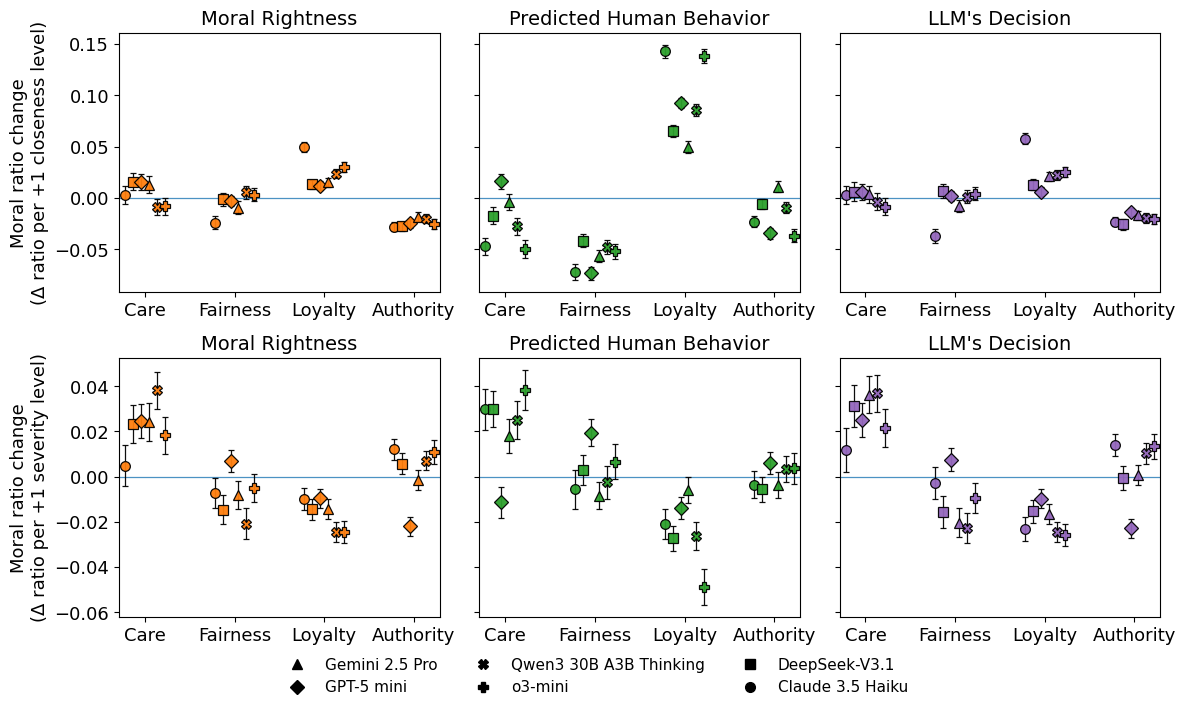

In [9]:
MORAL5 = ['care_ratio', 'fairness_ratio', 'loyalty_ratio', 'authority_ratio', 'sanctity_ratio']
MORAL4 = ['care_ratio', 'fairness_ratio', 'loyalty_ratio', 'authority_ratio']
MORAL_LABEL = {
    'care_ratio': 'Care', 'fairness_ratio': 'Fairness',
    'loyalty_ratio': 'Loyalty', 'authority_ratio': 'Authority',
}
MODEL_MARKERS = {
    'Claude 3.5 Haiku': 'o', 'Gemini 2.5 Pro': '^',
    'GPT-5 mini': 'D', 'o3-mini': 'P',
    'Qwen3 30B A3B Thinking': 'X', 'DeepSeek-V3.1': 's',
}


def preprocess_drop_sanctity(df):
    df = df[df[MORAL5].sum(axis=1) > 0].copy()
    sum4 = df[MORAL4].sum(axis=1)
    df = df[sum4 > 0].copy()
    df[MORAL4] = df[MORAL4].div(sum4, axis=0)
    df['closeness_level'] = pd.to_numeric(df['closeness_level'])
    df['severity_level'] = pd.to_numeric(df['severity_level'])
    return df


def fit_slopes(df, morals=MORAL4):
    rows = []
    for model in sorted(df['model'].unique()):
        for perspective in sorted(df['perspective'].unique()):
            sub = df[(df['model'] == model) & (df['perspective'] == perspective)]
            if len(sub) == 0:
                continue
            X = sm.add_constant(sub[['closeness_level', 'severity_level']].astype(float))
            for moral in morals:
                fit = sm.OLS(sub[moral].astype(float), X).fit(cov_type='HC3')
                ci = fit.conf_int()
                for term in ['closeness_level', 'severity_level']:
                    rows.append({
                        'model': model, 'perspective': perspective,
                        'moral': moral, 'term': term,
                        'coef': float(fit.params[term]),
                        'se': float(fit.bse[term]),
                        'ci_low': float(ci.loc[term, 0]),
                        'ci_high': float(ci.loc[term, 1]),
                        'p': float(fit.pvalues[term]),
                        'n': int(len(sub)),
                    })
    return pd.DataFrame(rows)


def plot_slopes_panel(ax, res, term, perspective, morals=MORAL4):
    dat = res[(res['term'] == term) & (res['perspective'] == perspective)].copy()
    if dat.empty:
        ax.set_axis_off(); return
    models = sorted(dat['model_display'].unique())
    x = np.arange(len(morals))
    jitter = np.linspace(-0.22, 0.22, num=len(models)) if len(models) > 1 else np.array([0.0])
    jit = {m: jitter[i] for i, m in enumerate(models)}
    color = PERSPECTIVE_COLORS.get(perspective, 'black')
    ax.axhline(0, linewidth=0.9, alpha=0.8)

    for moral_i, moral in enumerate(morals):
        for model in models:
            d = dat[(dat['model_display'] == model) & (dat['moral'] == moral)]
            if d.empty:
                continue
            d = d.iloc[0]
            mk = MODEL_MARKERS.get(model, 'o')
            xx = x[moral_i] + jit[model]
            yy = d['coef']
            yerr = [[yy - d['ci_low']], [d['ci_high'] - yy]]
            ax.errorbar(
                xx, yy, yerr=yerr, fmt=mk, markersize=7,
                color=color, ecolor='black', elinewidth=0.9, capsize=2,
                markeredgewidth=0.9, markeredgecolor='black',
                markerfacecolor=color, alpha=0.95,
            )
    ax.set_xticks(x)
    ax.set_xticklabels([MORAL_LABEL[m] for m in morals], fontsize=13)
    ax.set_title(PERSPECTIVE_TITLE_MAP.get(perspective, perspective), fontsize=14)
    ax.tick_params(axis='y', labelsize=13)
    ax.margins(x=0.02)


def build_model_legend(models_display):
    return [
        Line2D([0], [0], marker=MODEL_MARKERS.get(m, 'o'),
               linestyle='None',
               markerfacecolor='black', markeredgecolor='black',
               markersize=7, label=m)
        for m in models_display
    ]


df4 = preprocess_drop_sanctity(all_dilemma_score_df.copy())
res4 = fit_slopes(df4)
res4['model_display'] = res4['model'].map(MODEL_NAME_MAP).fillna(res4['model'])

fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharey='row')
perspective_order = ['prescriptive', 'descriptive', 'action']
for j, p in enumerate(perspective_order):
    plot_slopes_panel(axes[0, j], res4, term='closeness_level', perspective=p)
    plot_slopes_panel(axes[1, j], res4, term='severity_level', perspective=p)
axes[0, 0].set_ylabel('Moral ratio change\n(\u0394 ratio per +1 closeness level)', fontsize=13)
axes[1, 0].set_ylabel('Moral ratio change\n(\u0394 ratio per +1 severity level)', fontsize=13)

legend_order = [
    'Gemini 2.5 Pro', 'GPT-5 mini', 'Qwen3 30B A3B Thinking',
    'o3-mini', 'DeepSeek-V3.1', 'Claude 3.5 Haiku',
]
models_in_data = set(res4['model_display'].dropna())
legend_handles = build_model_legend([m for m in legend_order if m in models_in_data])
fig.legend(handles=legend_handles, loc='lower center',
           bbox_to_anchor=(0.5, -0.02), ncol=3, frameon=False, fontsize=11)
fig.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


## 7. Yes vs. No — moral profile shift with reporting

Bootstrap-CI bar plot: average moral-foundation usage when the model
answers Yes (Report) vs. No (Not report), per perspective.


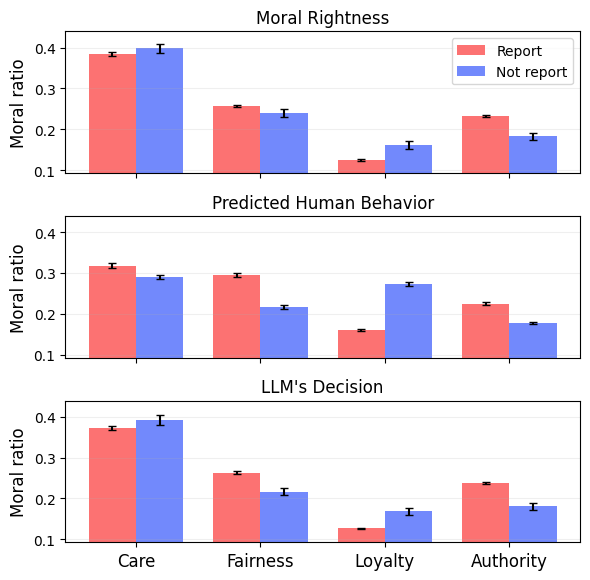

,perspective,answer,metric,metric_name,mean,ci95_low,ci95_high,n
0,prescriptive,Yes,care_ratio,Care,0.383908,0.379983,0.387835,21063
1,prescriptive,Yes,fairness_ratio,Fairness,0.257126,0.254481,0.259843,21063
2,prescriptive,Yes,loyalty_ratio,Loyalty,0.124751,0.122624,0.127003,21063
3,prescriptive,Yes,authority_ratio,Authority,0.232455,0.230147,0.234428,21063
4,prescriptive,No,care_ratio,Care,0.398432,0.386606,0.409644,2200


In [10]:
MORAL_COLS = ['care_ratio', 'fairness_ratio', 'loyalty_ratio', 'authority_ratio']
MORAL_LABELS = ['Care', 'Fairness', 'Loyalty', 'Authority']
PERSPECTIVES = ['prescriptive', 'descriptive', 'action']


def bootstrap_ci(x, n_boot=800, ci=95, seed=0, stat=np.mean):
    x = np.asarray(x); x = x[~np.isnan(x)]
    if len(x) == 0:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    boots = np.array([stat(rng.choice(x, size=len(x), replace=True)) for _ in range(n_boot)])
    lo = float(np.percentile(boots, (100 - ci) / 2))
    hi = float(np.percentile(boots, 100 - (100 - ci) / 2))
    return float(stat(x)), lo, hi


def summarize_yesno(df, perspectives=PERSPECTIVES, moral_cols=MORAL_COLS,
                    stat='mean', ci=95, n_boot=800, seed=0):
    d = df[df['answer'].isin(['Yes', 'No'])].copy()
    perspectives = [p for p in perspectives if p in set(d['perspective'].unique())]
    stat_fn = np.mean if stat == 'mean' else np.median
    name_map = dict(zip(MORAL_COLS, MORAL_LABELS))
    rows = []
    for p in perspectives:
        sub = d[d['perspective'] == p]
        for ans in ['Yes', 'No']:
            sub2 = sub[sub['answer'] == ans]
            for col in moral_cols:
                center, lo, hi = bootstrap_ci(
                    sub2[col].values, n_boot=n_boot, ci=ci, seed=seed, stat=stat_fn,
                )
                rows.append({
                    'perspective': p, 'answer': ans,
                    'metric': col, 'metric_name': name_map[col],
                    stat: center,
                    f'ci{ci}_low': lo, f'ci{ci}_high': hi,
                    'n': int(sub2[col].notna().sum()),
                })
    return pd.DataFrame(rows)


def plot_yesno_bars(
    df, perspectives=PERSPECTIVES, moral_cols=MORAL_COLS, labels=MORAL_LABELS,
    stat='mean', ci=95, n_boot=800, seed=0, figsize=(6, 6), save_path=None,
):
    color_report = '#fc7272'
    color_noreport = '#7289fc'
    summary = summarize_yesno(df, perspectives=perspectives, moral_cols=moral_cols,
                                stat=stat, ci=ci, n_boot=n_boot, seed=seed)
    y0 = max(0.0, summary[f'ci{ci}_low'].min() - 0.03)
    y1 = min(1.0, summary[f'ci{ci}_high'].max() + 0.03)
    perspectives = [p for p in perspectives if p in set(summary['perspective'].unique())]

    fig, axes = plt.subplots(len(perspectives), 1, figsize=figsize, sharex=True, sharey=True)
    if len(perspectives) == 1:
        axes = [axes]
    x = np.arange(len(moral_cols)); width = 0.38

    for ax, p in zip(axes, perspectives):
        sub = summary[summary['perspective'] == p]
        yes = sub[sub['answer'] == 'Yes'].set_index('metric').reindex(moral_cols)
        no = sub[sub['answer'] == 'No'].set_index('metric').reindex(moral_cols)
        yes_vals = yes[stat].values; no_vals = no[stat].values
        yes_err = np.vstack([yes_vals - yes[f'ci{ci}_low'].values, yes[f'ci{ci}_high'].values - yes_vals])
        no_err = np.vstack([no_vals - no[f'ci{ci}_low'].values, no[f'ci{ci}_high'].values - no_vals])
        ax.bar(x - width/2, yes_vals, width, yerr=yes_err, capsize=3,
               label='Report', color=color_report)
        ax.bar(x + width/2, no_vals, width, yerr=no_err, capsize=3,
               label='Not report', color=color_noreport)
        ax.set_title(PERSPECTIVE_TITLE_MAP.get(p, p))
        ax.set_ylabel('Moral ratio', fontsize=12)
        ax.set_ylim(y0, y1)
        ax.grid(axis='y', alpha=0.2)

    axes[-1].set_xticks(x)
    axes[-1].set_xticklabels(labels, fontsize=12)
    axes[0].legend(loc='upper right', frameon=True)
    fig.tight_layout(rect=[0, 0, 1, 0.985])
    if save_path:
        plt.savefig(save_path, format='pdf', bbox_inches='tight')
    return fig, axes, summary


fig, axes, summary_df = plot_yesno_bars(all_dilemma_score_df)
plt.show()
summary_df.head()
